In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import svd


# create matrix
A = np.array([[1, 2], [2, 3], [3, 4]])

# factorize
U, s, VT = svd(A, full_matrices=True)
V = VT.T

display(A)
display(U)
display(s)
display(V)

array([[1, 2],
       [2, 3],
       [3, 4]])

array([[-0.33809817,  0.84795222,  0.40824829],
       [-0.55064932,  0.17354729, -0.81649658],
       [-0.76320047, -0.50085764,  0.40824829]])

array([6.54675564, 0.37415323])

array([[-0.56959484, -0.82192562],
       [-0.82192562,  0.56959484]])

In [2]:
# first component of SVD (best rank-1 approximation)
U1 = U[:, 0].reshape(-1, 1)
s1 = s[0]
V1 = V[:, 0].reshape(-1, 1)

# display(U1)
# display(s1)
# display(V1)

A1 = s1 * U1 @ V1.T
display(A1)

# second component of SVD
U2 = U[:, 1].reshape(-1, 1)
s2 = s[1]
V2 = V[:, 1].reshape(-1, 1)

# display(U2)
# display(s2)
# display(V2)

A2 = s2 * U2 @ V2.T
display(A2)

# best rank-2 approximation is the sum of these first two components
# should also be equal to the original matrix since there are only two singular values
display(A1 + A2)

array([[1.26076746, 1.81928803],
       [2.05337032, 2.96301434],
       [2.84597319, 4.10674065]])

array([[-0.26076746,  0.18071197],
       [-0.05337032,  0.03698566],
       [ 0.15402681, -0.10674065]])

array([[1., 2.],
       [2., 3.],
       [3., 4.]])

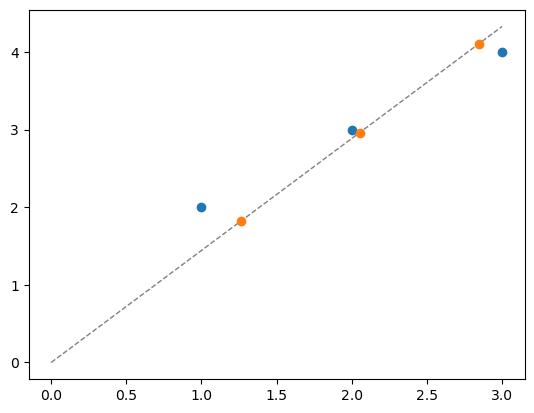

In [3]:
# plot the data
plt.scatter(A[:, 0], A[:, 1], label='A', zorder=1)

# plot the best rank-1 approximation
plt.scatter(A1[:, 0], A1[:, 1], label='A1', zorder=1)

# plot the first singular vector
x1, x2 = V1[0], V1[1]
x = np.array([0, 3])
y = (x2 / x1) * x
plt.plot(x, y, color='gray', linestyle='--', linewidth=1, zorder=0)

plt.show()

The best rank-1 represenation of the original dataset A is still in 2D, but only contains information in the direction of the first principal component.

This is interesting. I hadn't thought about it this way until I struggled on an exam question. I was trying to understand the difference between projecting onto a subset of of principal components (dimensionality reduction) and reconstructing the matrix in the original feature space using the principal components.

Constructing A1 as done above can be done with just the U and V vectors themselves. See below.

In [4]:
proj_mat_V1 = V1 @ V1.T
proj_mat_U1 = U1 @ U1.T

display(proj_mat_U1)
display(A)
display(proj_mat_V1)

array([[0.11431037, 0.18617352, 0.25803668],
       [0.18617352, 0.30321467, 0.42025582],
       [0.25803668, 0.42025582, 0.58247496]])

array([[1, 2],
       [2, 3],
       [3, 4]])

array([[0.32443828, 0.46816459],
       [0.46816459, 0.67556172]])

In [5]:
display(A1)
display(U1@U1.T@A)
display(A@V1@V1.T)

array([[1.26076746, 1.81928803],
       [2.05337032, 2.96301434],
       [2.84597319, 4.10674065]])

array([[1.26076746, 1.81928803],
       [2.05337032, 2.96301434],
       [2.84597319, 4.10674065]])

array([[1.26076746, 1.81928803],
       [2.05337032, 2.96301434],
       [2.84597319, 4.10674065]])

Now, we'll project onto the first PC and see the difference.

In [6]:
A @ V1

array([[-2.21344607],
       [-3.60496653],
       [-4.99648698]])

In [7]:
s1 * U1

array([[-2.21344607],
       [-3.60496653],
       [-4.99648698]])

In [8]:
display(A1)
display(V1)
display(U1)

array([[1.26076746, 1.81928803],
       [2.05337032, 2.96301434],
       [2.84597319, 4.10674065]])

array([[-0.56959484],
       [-0.82192562]])

array([[-0.33809817],
       [-0.55064932],
       [-0.76320047]])